# Vanilla GD, SGD and Mini-Batch GD using OOP

This notebook implements **Simple Linear Regression** on the supplied `Synthetic.csv` data using:

1. **Vanilla / Batch Gradient Descent (GD)**
2. **Stochastic Gradient Descent (SGD)**
3. **Mini-Batch Gradient Descent (MBGD)**

The three optimizers are implemented using an **Object-Oriented Programming (OOP)** design.

The original notebook used the model
$$\hat{y} = \theta_0 x + \theta_1$$

and standardized `X` before optimization. The same basic setup is retained here.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Load the supplied synthetic dataset.
# Change this path if the CSV is stored in a different location.
df = pd.read_csv("Synthetic.csv")

# Remove the index column present in the supplied CSV.
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()

,X,Y
0,37.454012,126.746701
1,95.071431,293.927975
2,73.199394,225.441700
3,59.865848,183.586508
4,15.601864,39.020372


In [3]:
# Extract predictor and response.
X = df[["X"]].values.astype(float)
y = df["Y"].values.astype(float).reshape(-1, 1)

# Standardize X, as done in the original notebook.
X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std

print("Number of observations:", X_scaled.shape[0])
print("Number of predictors:", X_scaled.shape[1])
print("X mean before scaling:", X_mean)
print("X standard deviation before scaling:", X_std)

Number of observations: 50
Number of predictors: 1
X mean before scaling: 44.59239043922611
X standard deviation before scaling: 28.59797785370301


## 1. Visualize the synthetic data

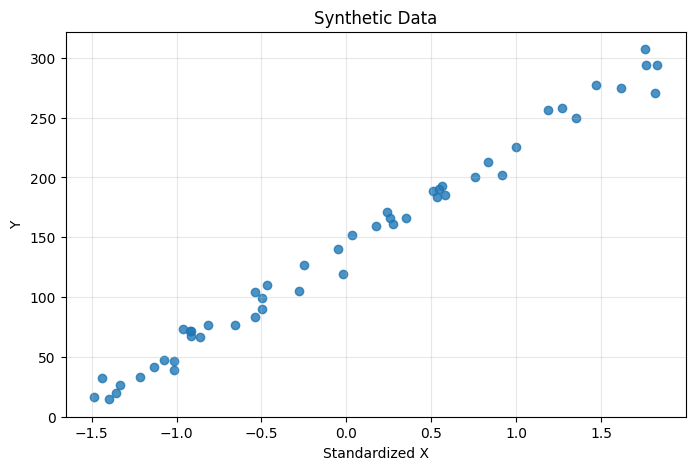

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled, y, alpha=0.8)
plt.xlabel("Standardized X")
plt.ylabel("Y")
plt.title("Synthetic Data")
plt.grid(alpha=0.3)
plt.show()

## 2. OOP design

We create a common base class `LinearRegressionGD`.

It contains the parts shared by all three methods:

- parameter initialization
- prediction
- MSE loss
- gradient calculation
- parameter updates
- convergence history
- `fit()` and `predict()`

The optimization-specific behavior is handled by subclasses:

- `VanillaGD`: uses the complete dataset for every update
- `SGD`: uses one randomly selected observation for every update
- `MiniBatchGD`: uses a small batch for every update

This avoids writing three completely separate regression implementations.

In [5]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, epochs=1000, tolerance=1e-8,
                 random_state=42):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance
        self.random_state = random_state

        # Model parameters:
        # y_hat = X * theta_0 + theta_1
        self.theta_0 = None
        self.theta_1 = None

        self.loss_history = []
        self.epoch_history = []
        self.n_updates = 0

    def initialize_parameters(self):
        # Start from zero for reproducibility and a fair comparison.
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.loss_history = []
        self.epoch_history = []
        self.n_updates = 0

    def predict(self, X):
        return X * self.theta_0 + self.theta_1

    def mse(self, X, y):
        y_hat = self.predict(X)
        return np.mean((y_hat - y) ** 2)

    def gradients(self, X_batch, y_batch):
        # For MSE = mean((y_hat - y)^2):
        # d(theta_0) = 2/n * sum[X * (y_hat-y)]
        # d(theta_1) = 2/n * sum[(y_hat-y)]
        y_hat = self.predict(X_batch)
        error = y_hat - y_batch
        n = len(X_batch)

        d_theta_0 = (2 / n) * np.sum(X_batch * error)
        d_theta_1 = (2 / n) * np.sum(error)

        return d_theta_0, d_theta_1

    def update_parameters(self, X_batch, y_batch):
        d_theta_0, d_theta_1 = self.gradients(X_batch, y_batch)

        self.theta_0 -= self.learning_rate * d_theta_0
        self.theta_1 -= self.learning_rate * d_theta_1

    def fit(self, X, y):
        raise NotImplementedError("Use one of the GD subclasses.")

    def summary(self):
        print("theta_0:", self.theta_0)
        print("theta_1:", self.theta_1)
        print("updates:", self.n_updates)
        if self.loss_history:
            print("final MSE:", self.loss_history[-1])

## 3. Vanilla / Batch Gradient Descent

In Vanilla GD, **all observations** are used to calculate the gradient before one parameter update.

Therefore, for one epoch:

$$\theta_j \leftarrow \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$$

There is **one parameter update per epoch**.

In [6]:
class VanillaGD(LinearRegressionGD):
    def fit(self, X, y):
        self.initialize_parameters()

        previous_loss = np.inf

        for epoch in range(1, self.epochs + 1):

            # One update uses the complete training dataset.
            self.update_parameters(X, y)
            self.n_updates += 1

            current_loss = self.mse(X, y)

            self.loss_history.append(current_loss)
            self.epoch_history.append(epoch)

            # Stop when improvement becomes very small.
            if abs(previous_loss - current_loss) < self.tolerance:
                break

            previous_loss = current_loss

        return self

## 4. Stochastic Gradient Descent

In SGD, **one observation at a time** is used to calculate the gradient.

For every epoch, the observations are shuffled and processed one by one.

Therefore, approximately:

$$\text{updates per epoch} = n$$


SGD usually has a noisier loss curve because each update is based on only one observation.

In [7]:
class SGD(LinearRegressionGD):
    def __init__(self, learning_rate=0.01, epochs=100, tolerance=1e-8,
                 random_state=42):
        super().__init__(learning_rate, epochs, tolerance, random_state)
        self.rng = np.random.default_rng(random_state)

    def fit(self, X, y):
        self.initialize_parameters()

        n = len(X)
        previous_loss = np.inf

        for epoch in range(1, self.epochs + 1):

            # Shuffle observations at the beginning of each epoch.
            indices = self.rng.permutation(n)

            for i in indices:
                X_batch = X[i:i+1]
                y_batch = y[i:i+1]

                self.update_parameters(X_batch, y_batch)
                self.n_updates += 1

            # Record full-dataset loss after the epoch.
            current_loss = self.mse(X, y)

            self.loss_history.append(current_loss)
            self.epoch_history.append(epoch)

            if abs(previous_loss - current_loss) < self.tolerance:
                break

            previous_loss = current_loss

        return self

## 5. Mini-Batch Gradient Descent

Mini-Batch GD is between Batch GD and SGD.

Instead of using:

- all observations, as in Vanilla GD, or
- one observation, as in SGD,

we use a small group of observations at each update.

For example, with `batch_size = 8`:

\[
\text{one update} \leftarrow 8\text{ observations}
\]

The loss curve is generally less noisy than SGD while requiring more updates than Vanilla GD.

In [8]:
class MiniBatchGD(LinearRegressionGD):
    def __init__(self, learning_rate=0.01, epochs=100, batch_size=8,
                 tolerance=1e-8, random_state=42):
        super().__init__(learning_rate, epochs, tolerance, random_state)
        self.batch_size = batch_size
        self.rng = np.random.default_rng(random_state)

    def fit(self, X, y):
        self.initialize_parameters()

        n = len(X)
        previous_loss = np.inf

        for epoch in range(1, self.epochs + 1):

            # Shuffle the complete dataset.
            indices = self.rng.permutation(n)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # Process one mini-batch at a time.
            for start in range(0, n, self.batch_size):
                end = start + self.batch_size

                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                self.update_parameters(X_batch, y_batch)
                self.n_updates += 1

            # Record full-dataset loss after each epoch.
            current_loss = self.mse(X, y)

            self.loss_history.append(current_loss)
            self.epoch_history.append(epoch)

            if abs(previous_loss - current_loss) < self.tolerance:
                break

            previous_loss = current_loss

        return self

## 6. Train all three models

The same standardized synthetic data and the same initial parameter values are used for a fair comparison.

The learning rates are chosen separately because the three methods have different update behavior.

In [9]:
vanilla_gd = VanillaGD(
    learning_rate=0.05,
    epochs=1000,
    tolerance=1e-10
)

sgd = SGD(
    learning_rate=0.005,
    epochs=100,
    tolerance=1e-10,
    random_state=42
)

mbgd = MiniBatchGD(
    learning_rate=0.01,
    epochs=100,
    batch_size=8,
    tolerance=1e-10,
    random_state=42
)

vanilla_gd.fit(X_scaled, y)
sgd.fit(X_scaled, y)
mbgd.fit(X_scaled, y)

## 7. Compare the fitted parameters

In [10]:
results = pd.DataFrame({
    "Method": ["Vanilla GD", "SGD", "Mini-Batch GD"],
    "theta_0": [vanilla_gd.theta_0, sgd.theta_0, mbgd.theta_0],
    "theta_1": [vanilla_gd.theta_1, sgd.theta_1, mbgd.theta_1],
    "Final MSE": [
        vanilla_gd.mse(X_scaled, y),
        sgd.mse(X_scaled, y),
        mbgd.mse(X_scaled, y)
    ],
    "Updates": [
        vanilla_gd.n_updates,
        sgd.n_updates,
        mbgd.n_updates
    ],
    "Epochs completed": [
        len(vanilla_gd.loss_history),
        len(sgd.loss_history),
        len(mbgd.loss_history)
    ]
})

results

,Method,theta_0,theta_1,Final MSE,Updates,Epochs completed
0,Vanilla GD,85.154947,140.747701,82.307114,151,151
1,SGD,85.191809,140.630425,82.322230,5000,100
2,Mini-Batch GD,84.790943,140.547475,82.479719,700,100


## 8. Plot the fitted regression lines

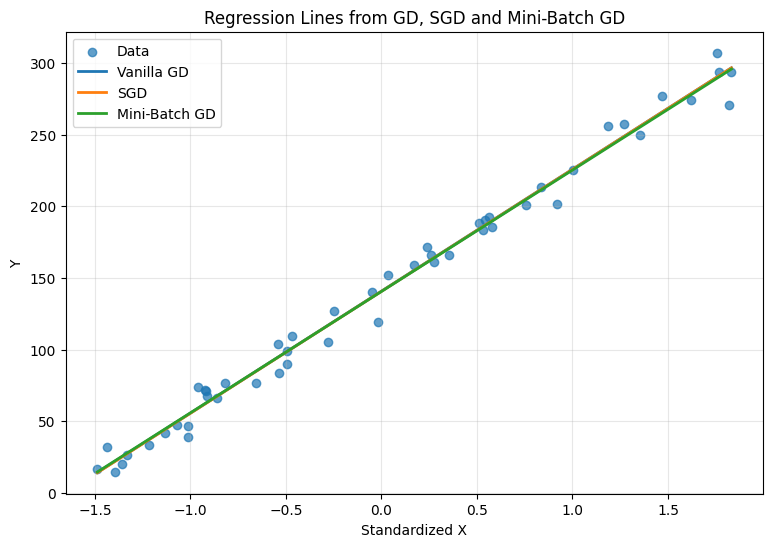

In [11]:
x_plot = np.linspace(X_scaled.min(), X_scaled.max(), 200).reshape(-1, 1)

plt.figure(figsize=(9, 6))
plt.scatter(X_scaled, y, label="Data", alpha=0.7)

plt.plot(
    x_plot,
    vanilla_gd.predict(x_plot),
    linewidth=2,
    label="Vanilla GD"
)

plt.plot(
    x_plot,
    sgd.predict(x_plot),
    linewidth=2,
    label="SGD"
)

plt.plot(
    x_plot,
    mbgd.predict(x_plot),
    linewidth=2,
    label="Mini-Batch GD"
)

plt.xlabel("Standardized X")
plt.ylabel("Y")
plt.title("Regression Lines from GD, SGD and Mini-Batch GD")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 9. Compare convergence

The loss stored for Vanilla GD, SGD and Mini-Batch GD is the **full-dataset MSE after each epoch**.

Expected behavior:

- **Vanilla GD:** smooth and stable convergence
- **SGD:** noisier convergence because every individual observation causes an update
- **Mini-Batch GD:** intermediate behavior; usually smoother than SGD and faster-moving than full Batch GD

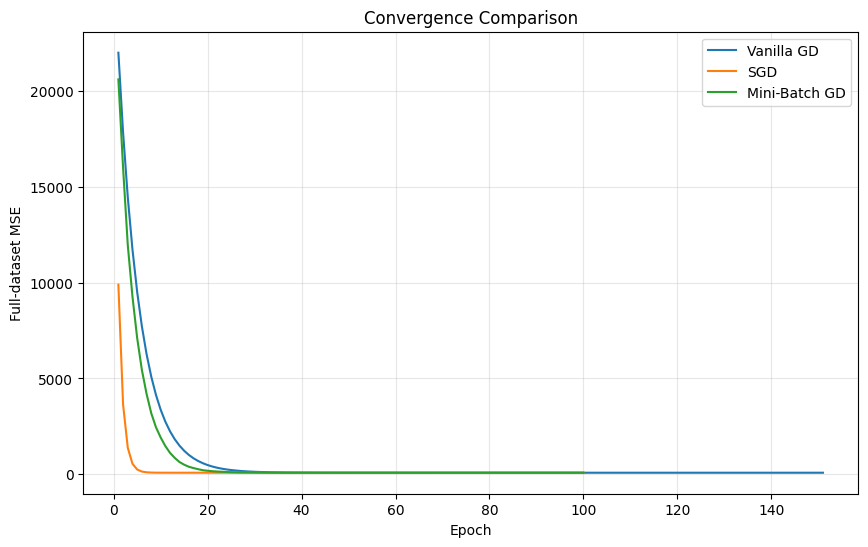

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(
    vanilla_gd.epoch_history,
    vanilla_gd.loss_history,
    label="Vanilla GD"
)

plt.plot(
    sgd.epoch_history,
    sgd.loss_history,
    label="SGD"
)

plt.plot(
    mbgd.epoch_history,
    mbgd.loss_history,
    label="Mini-Batch GD"
)

plt.xlabel("Epoch")
plt.ylabel("Full-dataset MSE")
plt.title("Convergence Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Loss comparison on a log scale

A logarithmic y-axis makes it easier to see the convergence behavior when the loss becomes very small.

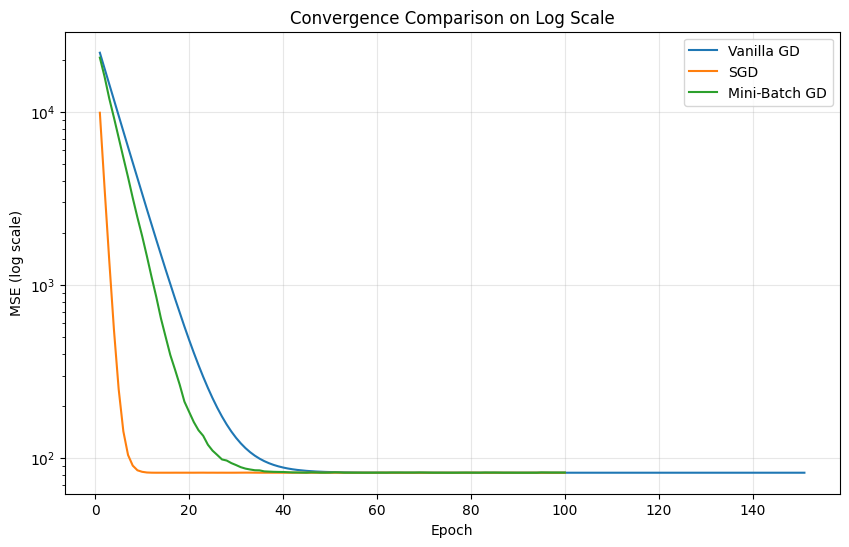

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    vanilla_gd.epoch_history,
    vanilla_gd.loss_history,
    label="Vanilla GD"
)

plt.plot(
    sgd.epoch_history,
    sgd.loss_history,
    label="SGD"
)

plt.plot(
    mbgd.epoch_history,
    mbgd.loss_history,
    label="Mini-Batch GD"
)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.title("Convergence Comparison on Log Scale")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11. Predict for a new X value

Because the model was trained using standardized `X`, a new raw `X` value must also be standardized before prediction.

$$X_{\text{scaled}} = \frac{X - \bar{X}}{s_X}$$

In [14]:
def predict_from_raw_x(model, raw_x):
    raw_x = np.asarray(raw_x, dtype=float).reshape(-1, 1)
    scaled_x = (raw_x - X_mean) / X_std
    return model.predict(scaled_x)

new_x = 60

print("Raw X:", new_x)
print("Vanilla GD prediction:", predict_from_raw_x(vanilla_gd, new_x)[0, 0])
print("SGD prediction:", predict_from_raw_x(sgd, new_x)[0, 0])
print("Mini-Batch GD prediction:", predict_from_raw_x(mbgd, new_x)[0, 0])

Raw X: 60
Vanilla GD prediction: 186.62626577501365
SGD prediction: 186.5288492316426
Mini-Batch GD prediction: 186.22992629934782


## 12. Important conceptual comparison

| Method | Observations per update | Updates per epoch | Gradient noise | Typical behavior |
|---|---:|---:|---|---|
| Vanilla GD | All observations | 1 | Low | Smooth, stable |
| SGD | 1 | n | High | Fast but noisy |
| Mini-Batch GD | batch size | approximately n / batch size | Medium | Balance of speed and stability |

For this dataset, the exact number of epochs and updates depends on the convergence criterion and the chosen hyperparameters.

### Key OOP idea

All three classes inherit common functionality from `LinearRegressionGD`.

Only the `fit()` strategy changes:

- `VanillaGD.fit()` → full dataset for every update
- `SGD.fit()` → one observation per update
- `MiniBatchGD.fit()` → a fixed-size batch per update

This is the main reason OOP is useful here: the common regression logic is written once, while each optimizer specializes the training procedure.

## 13. Final model equations

For every optimizer, the fitted model has the same form:
$$\boxed{\hat{y} = \theta_0 X_{\text{scaled}} + \theta_1}$$

The difference is **not the regression model itself**. The difference is the way the gradient is estimated and how frequently the parameters are updated.

- Vanilla GD calculates the gradient using all observations.
- SGD calculates the gradient using one observation.
- Mini-Batch GD calculates the gradient using a subset of observations.